# 05. Machine Learning Baselines

This notebook establishes benchmarks for predicting the **next-month product risk class**. It is designed as a bridge between feature engineering and more advanced model development.

The purpose is not to claim a final production model. Instead, we answer four practical questions:

1. Does the feature set contain predictive signal beyond a trivial rule?
2. Can a simple model identify the rare high-risk class?
3. How many false alerts would the model create?
4. Which features show the strongest relationship with the target?

**Primary input:** the ML-ready train, validation, test and optional scoring files created in `04_feature_engineering_portfolio.ipynb`.


## Notebook roadmap

1. Setup
2. Load the ML-ready feature matrices and optional identifier tables
3. validate schema, missing values, feature alignment and chronological separation
4. Examine target imbalance before choosing metrics
5. Establish a majority-class reference baseline
6. Train Gaussian Naive Bayes as a simple probabilistic baseline
7. Train class-weighted logistic regression as an interpretable linear baseline
8. Compare models on validation data 
9. Evaluate the selected baseline on the untouched test period
10. inspect feature relationships and model coefficients
11. Refit the selected baseline on all labeled history and score the latest unlabeled month
12. Export results, predictions, models, documentation and quality checks

## 1. Setup

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_fscore_support,
    roc_auc_score)
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import label_binarize


pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 42
TARGET_COL = "next_month_risk_label"
RISK_LABELS = [0, 1, 2]
LABEL_NAMES = {
    0: "Low Risk",
    1: "Medium Risk",
    2: "High Risk"}

INPUT_DIR = Path("../data/full_data/feature_engineering")

OUTPUT_DIR = Path("../data/full_data/ml_baseline")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input folder:  {INPUT_DIR}")
print(f"Output folder: {OUTPUT_DIR}")
print(f"Random seed:   {RANDOM_SEED}")


Input folder:  ..\data\full_data\feature_engineering
Output folder: ..\data\full_data\ml_baseline
Random seed:   42


## 2. Load the feature-engineering outputs


In [2]:
# load labeled ML matrices plus optional scoring and identifier files
def load_feature_engineering_outputs(input_dir=INPUT_DIR):
    required_paths = {
        "train": input_dir / "train_feature_engineered_ml_ready.csv",
        "valid": input_dir / "valid_feature_engineered_ml_ready.csv",
        "test": input_dir / "test_feature_engineered_ml_ready.csv"}
    missing = [str(path) for path in required_paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Missing required feature-engineering outputs:\n- " + "\n- ".join(missing))

    matrices = {
        split: pd.read_csv(path)
        for split, path in required_paths.items()}

    scoring_path = input_dir / "scoring_feature_engineered_ml_ready.csv"
    matrices["scoring"] = (
        pd.read_csv(scoring_path) if scoring_path.exists() else None)

    id_tables = {}
    for split in ["train", "valid", "test", "scoring"]:
        id_path = input_dir / f"{split}_feature_engineered_ids.csv"
        id_tables[split] = pd.read_csv(id_path) if id_path.exists() else None

    return matrices, id_tables

In [3]:
matrices, id_tables = load_feature_engineering_outputs()

input_summary = pd.DataFrame(
    [
        {
            "split": split,
            "rows": 0 if frame is None else len(frame),
            "columns": 0 if frame is None else frame.shape[1],
            "target_available": frame is not None and TARGET_COL in frame.columns,
            "identifier_file_available": id_tables.get(split) is not None}
        for split, frame in matrices.items()])
display(input_summary)


,split,rows,columns,target_available,identifier_file_available
0,train,82000,236,True,True
1,valid,16000,236,True,True
2,test,20000,236,True,True
3,scoring,2000,235,False,True


check: train, validation and test must contain the target. The scoring table should not contain it because its future outcome is not known yet. 

Identifier files are kept separately so product and region IDs cannot accidentally become model features.

In [4]:
display(matrices["train"].head(3))

print("First 12 columns:")
print(matrices["train"].columns[:12].tolist())
print("\nLast 8 columns:")
print(matrices["train"].columns[-8:].tolist())

,units_sold,revenue,unique_customers,avg_discount_pct,units_lag_1m,units_lag_3m,revenue_lag_1m,rolling_units_mean_3m,rolling_units_mean_6m,rolling_units_std_3m,volatility_3m,mom_units_growth_pct,customer_count_growth_pct,trend_slope_3m,trend_slope_6m,stockout_flag,backorder_units,market_demand_index,competitor_pressure_index,campaign_flag,website_visits,demo_requests,risk_factor_sales_drop,risk_factor_customer_drop,risk_factor_volatility,risk_factor_under_trend,is_declining_product,is_new_product,base_list_price_eur,base_unit_cost_eur,target_margin_pct,product_growth_factor,fx_to_eur,market_growth_factor,margin_factor,order_count,active_sales_reps,avg_asp_eur,gross_profit_eur,cogs_eur,discount_value_eur,outlier_order_count,gross_margin_pct,avg_customer_size_score,avg_base_churn_probability,enterprise_customer_count,high_churn_customer_count,covered_annual_quota_eur,no_sales_flag,opening_stock_units,production_units,ending_stock_units,zero_stock_flag,inventory_value_eur,supply_coverage_ratio,standard_unit_cost_eur,actual_unit_cost_eur,cost_variance_eur,cost_variance_pct,return_units,...,pipeline_value_per_customer,marketing_efficiency_score,commercial_pressure_score,revenue_at_risk_proxy,product_line__Accessories,product_line__Components,product_line__IT Devices,product_line__Industrial Tech,product_line__Legacy Products,product_line__Medical Devices,product_line__Services,product_line____UNSEEN__,product_category__Accessory Kit,product_category__Connectivity Module,product_category__Industrial Scanner,product_category__Laptop Pro,product_category__Laptop Standard,product_category__Legacy Workstation,product_category__Medical Sensor,product_category__Monitoring Device,product_category__Service Contract,product_category__Tablet Enterprise,product_category____UNSEEN__,region__APAC,region__Benelux,region__DACH,region__Eastern Europe,region__North America,region__Northern Europe,region__Southern Europe,region__Western Europe,region____UNSEEN__,lifecycle_stage__Decline,lifecycle_stage__Growth,lifecycle_stage__Mature,lifecycle_stage__New,lifecycle_stage____UNSEEN__,dominant_margin_category__High Margin,dominant_margin_category__Low Margin,dominant_margin_category__Medium Margin,dominant_margin_category____UNSEEN__,dominant_order_size_category__Large Order,dominant_order_size_category__Medium Order,dominant_order_size_category__Small Order,dominant_order_size_category____UNSEEN__,dominant_rep_seniority__Junior,dominant_rep_seniority__Key Account,dominant_rep_seniority__Professional,dominant_rep_seniority__Senior,dominant_rep_seniority__Unknown,dominant_rep_seniority____UNSEEN__,campaign_channel__Content,campaign_channel__Email,campaign_channel__No Active Campaign,campaign_channel__Paid Search,campaign_channel__Partner,campaign_channel__Trade Fair,campaign_channel__Webinar,campaign_channel____UNSEEN__,next_month_risk_label
0,0.6724,0.8967,0.9684,-0.9029,-0.4051,-0.3913,-0.3684,-0.2463,-0.2366,-0.1900,-0.0165,-0.1550,-0.2135,-0.0045,-0.0160,-0.0425,-0.0171,-0.7626,0.8722,-0.4751,-0.3385,-0.4166,-0.7332,-0.6644,-1.8886,-0.8597,1.7092,-0.2637,0.6085,0.5683,-0.3342,0.0473,0.5486,0.2229,0.0952,0.9482,0.9737,0.6746,0.7770,0.8861,0.3022,-0.1105,-0.1440,-0.2466,-0.8999,1.3171,-0.3298,0.7213,-0.8748,-0.2129,0.2427,-0.2871,-0.0425,0.1975,-2.0149,0.5122,0.5891,1.3996,1.2007,-0.0987,...,0.2839,-0.0540,-0.9179,-0.1551,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1
1,-0.5834,-0.4279,-0.8590,-0.0442,0.6906,-0.3913,0.9166,-0.2463,-0.2366,-0.1900,-0.0165,-0.2121,-0.9436,-0.0045,-0.0160,-0.0425,-0.0171,-0.5950,1.0888,-0.4751,-0.3443,-0.3770,1.3638,1.5050,-1.8886,-0.8597,1.7092,-0.2637,0.6085,0.5683,-0.3342,0.0473,0.5486,0.2229,0.0952,-0.8552,-0.8561,-0.0855,-0.3703,-0.4230,-0.3849,-0.1105,-0.0632,-0.1649,-0.1052,-0.5035,-0.3298,-0.7857,1.1431,-0.1989,-0.1827,-0.1971,-0.0425,-0.2233,0.0032,0.5801,0.5514,-0.3074,-0.4056,-0.0987,...,-0.2346,-0.0540,0.6792,-0.3292,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0

First 12 columns:
['units_sold', 'revenue', 'unique_customers', 'avg_discount_pct', 'units_lag_1m', 'units_lag_3m', 'revenue_lag_1m', 'rolling_units_mean_3m', 'rolling_units_mean_6m', 'rolling_units_std_3m', 'volatility_3m', 'mom_units_growth_pct']

Last 8 columns:
['campaign_channel__Email', 'campaign_channel__No Active Campaign', 'campaign_channel__Paid Search', 'campaign_channel__Partner', 'campaign_channel__Trade Fair', 'campaign_channel__Webinar', 'campaign_channel____UNSEEN__', 'next_month_risk_label']


## 3. Validate

In [5]:
#Return the numeric feature matrix and integer target vector
def split_features_and_target(frame):
    if TARGET_COL not in frame.columns:
        raise KeyError(f"Required target column is missing: {TARGET_COL}")
    X = frame.drop(columns=TARGET_COL).copy()
    y = frame[TARGET_COL].astype(int).copy()
    return X, y

X_train, y_train = split_features_and_target(matrices["train"])
X_valid, y_valid = split_features_and_target(matrices["valid"])
X_test, y_test = split_features_and_target(matrices["test"])
X_scoring = None if matrices["scoring"] is None else matrices["scoring"].copy()

split_shapes = pd.DataFrame(
    {
        "split": ["train", "validation", "test", "scoring"],
        "rows": [len(X_train), len(X_valid), len(X_test), 0 if X_scoring is None else len(X_scoring)],
        "features": [X_train.shape[1], X_valid.shape[1], X_test.shape[1], 0 if X_scoring is None else X_scoring.shape[1]]})
display(split_shapes)


,split,rows,features
0,train,82000,235
1,validation,16000,235
2,test,20000,235
3,scoring,2000,235


In [6]:
def matrix_quality_row(split, X, y=None):
    values = X.to_numpy(dtype=float)
    return {
        "split": split,
        "rows": len(X),
        "features": X.shape[1],
        "duplicate_column_names": int(X.columns.duplicated().sum()),
        "missing_feature_values": int(X.isna().sum().sum()),
        "infinite_feature_values": int(np.isinf(values).sum()),
        "missing_target_values": 0 if y is None else int(y.isna().sum()),
        "memory_mb": float(X.memory_usage(deep=True).sum() / 1024**2)}


matrix_quality = pd.DataFrame(
    [
        matrix_quality_row("train", X_train, y_train),
        matrix_quality_row("validation", X_valid, y_valid),
        matrix_quality_row("test", X_test, y_test),
        *(
            [matrix_quality_row("scoring", X_scoring)]
            if X_scoring is not None
            else [])])
display(matrix_quality)

feature_alignment = {
    "validation_matches_train": X_valid.columns.tolist() == X_train.columns.tolist(),
    "test_matches_train": X_test.columns.tolist() == X_train.columns.tolist(),
    "scoring_matches_train": X_scoring is None or X_scoring.columns.tolist() == X_train.columns.tolist()}
print("Feature alignment:", feature_alignment)

assert all(feature_alignment.values())
assert matrix_quality["duplicate_column_names"].eq(0).all()
assert matrix_quality["missing_feature_values"].eq(0).all()
assert matrix_quality["infinite_feature_values"].eq(0).all()
assert set(pd.concat([y_train, y_valid, y_test]).unique()).issubset(RISK_LABELS)
assert TARGET_COL not in X_train.columns
assert not any(column.endswith("_id") for column in X_train.columns)

print("The feature matrices satisfy the modeling contract.")


,split,rows,features,duplicate_column_names,missing_feature_values,infinite_feature_values,missing_target_values,memory_mb
0,train,82000,235,0,0,0,0,147.0186
1,validation,16000,235,0,0,0,0,28.6866
2,test,20000,235,0,0,0,0,35.8583
3,scoring,2000,235,0,0,0,0,3.5859


Feature alignment: {'validation_matches_train': True, 'test_matches_train': True, 'scoring_matches_train': True}
The feature matrices satisfy the modeling contract.


The next check uses the separate identifier files. It confirms both row alignment and chronological ordering without adding IDs or dates to the model itself.

In [7]:
chronology_rows = []
for split, y_values in [
    ("train", y_train),
    ("valid", y_valid),
    ("test", y_test),
]:
    ids = id_tables[split]
    if ids is None:
        continue
    assert len(ids) == len(y_values)
    assert ids[TARGET_COL].astype(int).reset_index(drop=True).equals(
        y_values.reset_index(drop=True)
    )
    months = pd.PeriodIndex(ids["target_month"], freq="M")
    chronology_rows.append(
        {
            "split": split,
            "first_target_month": str(months.min()),
            "last_target_month": str(months.max()),
            "rows": len(ids)})

chronology_summary = pd.DataFrame(chronology_rows)
if not chronology_summary.empty:
    display(chronology_summary)
    train_end = pd.Period(chronology_summary.loc[chronology_summary["split"] == "train", "last_target_month"].iloc[0], freq="M")
    valid_start = pd.Period(chronology_summary.loc[chronology_summary["split"] == "valid", "first_target_month"].iloc[0], freq="M")
    valid_end = pd.Period(chronology_summary.loc[chronology_summary["split"] == "valid", "last_target_month"].iloc[0], freq="M")
    test_start = pd.Period(chronology_summary.loc[chronology_summary["split"] == "test", "first_target_month"].iloc[0], freq="M")
    assert train_end < valid_start <= valid_end < test_start
    print("Chronological split order is valid: train → validation → test.")
else:
    print("Identifier files were not found; chronological ranges cannot be displayed here.")


,split,first_target_month,last_target_month,rows
0,train,2021-02,2024-06,82000
1,valid,2024-07,2025-02,16000
2,test,2025-03,2025-12,20000


Chronological split order is valid: train → validation → test.


## 4. Understand the target before modeling


Accuracy can be misleading when almost every row is low risk. Therefore, we inspect the class distribution before training and later emphasize macro F1, high-risk precision/recall, high-risk F2, alert rate and false-alarm rate.

In [8]:
# Return one row per expected risk class, including absent classes
def target_distribution(y, split_name=None):
    counts = pd.Series(y).value_counts().reindex(RISK_LABELS, fill_value=0)
    result = pd.DataFrame(
        {
            "label": RISK_LABELS,
            "label_name": [LABEL_NAMES[label] for label in RISK_LABELS],
            "rows": counts.to_numpy(dtype=int),
            "share": counts.to_numpy(dtype=float) / len(y)})
    result["share_pct"] = result["share"] * 100
    if split_name is not None:
        result.insert(0, "split", split_name)
    return result


train_target_distribution = target_distribution(y_train, "train")
valid_target_distribution = target_distribution(y_valid, "validation")
test_target_distribution = target_distribution(y_test, "test")
target_distribution_all = pd.concat(
    [train_target_distribution, valid_target_distribution, test_target_distribution],
    ignore_index=True)
display(target_distribution_all)


,split,label,label_name,rows,share,share_pct
0,train,0,Low Risk,12773,0.1558,15.5768
1,train,1,Medium Risk,42062,0.5130,51.2951
2,train,2,High Risk,27165,0.3313,33.1280
3,validation,0,Low Risk,1932,0.1207,12.0750
4,validation,1,Medium Risk,8467,0.5292,52.9188
5,validation,2,High Risk,5601,0.3501,35.0063
6,test,0,Low Risk,2589,0.1295,12.9450
7,test,1,Medium Risk,10594,0.5297,52.9700
8,test,2,High Risk,6817,0.3408,34.0850


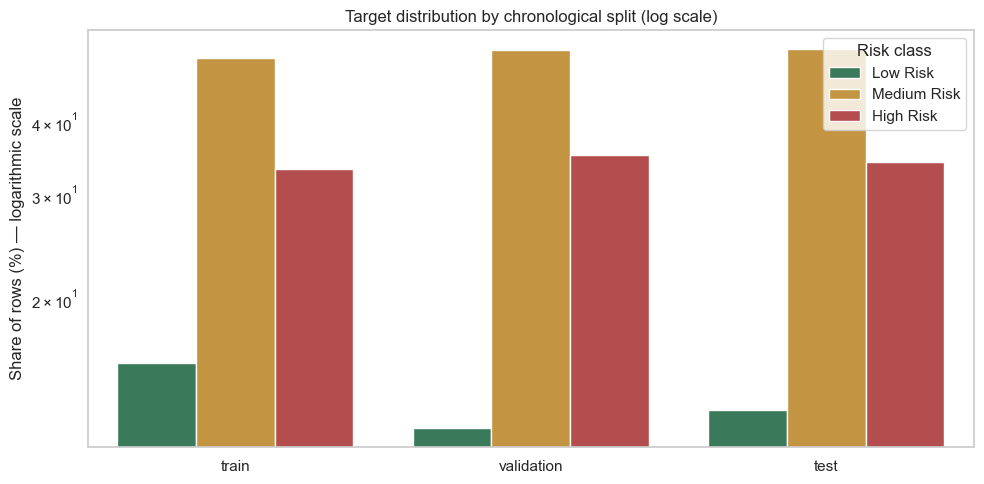

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=target_distribution_all,
    x="split",
    y="share_pct",
    hue="label_name",
    palette=["#2F855A", "#D99A2B", "#C53D3D"],
    ax=ax)
ax.set_yscale("log")
ax.set_title("Target distribution by chronological split (log scale)")
ax.set_xlabel("")
ax.set_ylabel("Share of rows (%) — logarithmic scale")
ax.legend(title="Risk class")
plt.tight_layout()
plt.show()


In [10]:
train_low_count = int((y_train == 0).sum())
train_high_count = int((y_train == 2).sum())
imbalance_ratio = np.inf if train_high_count == 0 else train_low_count / train_high_count
high_risk_share = float((y_train == 2).mean())

print(f"Training high-risk rows: {train_high_count:,}")
print(f"Training high-risk share: {high_risk_share:.4%}")
print(f"Low-risk to high-risk ratio: {imbalance_ratio:,.1f}:1")

if high_risk_share < 0.005:
    print(
        "\nInterpretation: high risk is extremely rare. Accuracy alone is not useful, "
        "and validation metrics will be statistically unstable because only a few "
        "high-risk examples are available.")


Training high-risk rows: 27,165
Training high-risk share: 33.1280%
Low-risk to high-risk ratio: 0.5:1


## 5. Evaluation metrics and helpers

The evaluation helper standardizes calculations across models. It returns 3 objects:

- one summary row for model comparison
- a class-level precision/recall/F1 table
- a confusion matrix containing the raw prediction counts

**High-risk F2** weights recall more strongly than precision, which matches an early-warning use case where missing a genuine risk can be more costly than reviewing an extra alert. Precision and alert rate remain visible so this choice cannot hide operational workload.


In [11]:
# Place model probabilities in the fixed class order 0, 1, 2
def align_probabilities(probabilities, model_classes):
    aligned = np.zeros((len(probabilities), len(RISK_LABELS)), dtype=float)
    class_to_position = {int(label): position for position, label in enumerate(model_classes)}
    for output_position, label in enumerate(RISK_LABELS):
        if label in class_to_position:
            aligned[:, output_position] = probabilities[:, class_to_position[label]]
    return aligned

# Calculate statistical and operational multiclass metrics
def evaluate_predictions(model_name, split, y_true, y_pred, y_probability):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=RISK_LABELS,
        zero_division=0)

    class_report = pd.DataFrame(
        {
            "label": RISK_LABELS,
            "label_name": [LABEL_NAMES[label] for label in RISK_LABELS],
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "support": support.astype(int)})

    matrix = confusion_matrix(y_true, y_pred, labels=RISK_LABELS)
    matrix_df = pd.DataFrame(
        matrix,
        index=[f"actual_{LABEL_NAMES[label]}" for label in RISK_LABELS],
        columns=[f"pred_{LABEL_NAMES[label]}" for label in RISK_LABELS])

    high_position = RISK_LABELS.index(2)
    high_precision = float(precision[high_position])
    high_recall = float(recall[high_position])
    high_f1 = float(f1[high_position])
    high_f2 = (
        5 * high_precision * high_recall / (4 * high_precision + high_recall)
        if (4 * high_precision + high_recall) > 0
        else 0.0)

    predicted_high = np.asarray(y_pred) == 2
    actual_not_high = np.asarray(y_true) != 2
    false_high_alerts = int((predicted_high & actual_not_high).sum())
    false_alarm_rate = (
        false_high_alerts / actual_not_high.sum()
        if actual_not_high.sum() > 0
        else np.nan)

    binary_targets = label_binarize(y_true, classes=RISK_LABELS)
    try:
        macro_roc_auc = roc_auc_score(
            binary_targets,
            y_probability,
            average="macro",
            multi_class="ovr")
    except ValueError:
        macro_roc_auc = np.nan

    try:
        macro_pr_auc = average_precision_score(
            binary_targets,
            y_probability,
            average="macro")
        high_risk_pr_auc = average_precision_score(
            (np.asarray(y_true) == 2).astype(int),
            y_probability[:, high_position])
    except ValueError:
        macro_pr_auc = np.nan
        high_risk_pr_auc = np.nan

    summary = {
        "model": model_name,
        "split": split,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "high_risk_precision": high_precision,
        "high_risk_recall": high_recall,
        "high_risk_f1": high_f1,
        "high_risk_f2": float(high_f2),
        "alert_rate": float((np.asarray(y_pred) > 0).mean()),
        "high_risk_alert_rate": float(predicted_high.mean()),
        "false_alarm_rate": float(false_alarm_rate),
        "macro_roc_auc_ovr": float(macro_roc_auc),
        "macro_pr_auc": float(macro_pr_auc),
        "high_risk_pr_auc": float(high_risk_pr_auc),
        "log_loss": float(log_loss(y_true, y_probability, labels=RISK_LABELS))}
    return summary, class_report, matrix_df


## 6. Baseline 1 — Majority class


This model always predicts the most common training class. It provides the minimum reference point: a useful ML model must add value beyond this strategy, especially for medium- and high-risk detection.


In [12]:
models = {}
validation_outputs = {}
test_outputs = {}

majority_model = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
majority_model.fit(X_train, y_train)
models["majority_class"] = majority_model

majority_valid_prediction = majority_model.predict(X_valid)
majority_valid_probability = align_probabilities(
    majority_model.predict_proba(X_valid),
    majority_model.classes_)
validation_outputs["majority_class"] = evaluate_predictions(
    "majority_class",
    "valid",
    y_valid,
    majority_valid_prediction,
    majority_valid_probability)

display(pd.Series(majority_valid_prediction).value_counts().rename("predicted_rows").to_frame())
display(pd.DataFrame([validation_outputs["majority_class"][0]]).round(4))


,predicted_rows
1,16000


,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,high_risk_precision,high_risk_recall,high_risk_f1,high_risk_f2,alert_rate,high_risk_alert_rate,false_alarm_rate,macro_roc_auc_ovr,macro_pr_auc,high_risk_pr_auc,log_loss
0,majority_class,valid,0.5292,0.3333,0.2307,0.3663,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.5000,0.3333,0.3501,16.9698


A very high accuracy is expected here because low risk dominates the data. The zero high-risk recall reveals why that accuracy is not operationally useful.


## 7. Baseline 2 — Gaussian Naive Bayes


Gaussian Naive Bayes is fast and produces probabilities, but it assumes conditional feature independence and Gaussian class distributions. Those assumptions are imperfect for correlated rolling features and one-hot indicators, so this is a **signal-check baseline**, not a likely final model.


In [13]:
gaussian_nb_model = GaussianNB(var_smoothing=1e-4)
gaussian_nb_model.fit(X_train, y_train)
models["gaussian_naive_bayes"] = gaussian_nb_model

gaussian_valid_prediction = gaussian_nb_model.predict(X_valid)
gaussian_valid_probability = align_probabilities(
    gaussian_nb_model.predict_proba(X_valid),
    gaussian_nb_model.classes_)
validation_outputs["gaussian_naive_bayes"] = evaluate_predictions(
    "gaussian_naive_bayes",
    "valid",
    y_valid,
    gaussian_valid_prediction,
    gaussian_valid_probability)

gaussian_probability_check = pd.DataFrame(
    {
        "minimum_row_probability_sum": [gaussian_valid_probability.sum(axis=1).min()],
        "maximum_row_probability_sum": [gaussian_valid_probability.sum(axis=1).max()],
        "predicted_medium_or_high_share": [(gaussian_valid_prediction > 0).mean()],
        "predicted_high_share": [(gaussian_valid_prediction == 2).mean()]})
display(gaussian_probability_check)


,minimum_row_probability_sum,maximum_row_probability_sum,predicted_medium_or_high_share,predicted_high_share
0,1.0000,1.0000,0.7089,0.3297


In [14]:
gaussian_summary, gaussian_report, gaussian_matrix = validation_outputs["gaussian_naive_bayes"]
display(pd.DataFrame([gaussian_summary]).round(4))
display(gaussian_matrix)
display(gaussian_report.round(4))

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,high_risk_precision,high_risk_recall,high_risk_f1,high_risk_f2,alert_rate,high_risk_alert_rate,false_alarm_rate,macro_roc_auc_ovr,macro_pr_auc,high_risk_pr_auc,log_loss
0,gaussian_naive_bayes,valid,0.5564,0.6224,0.5460,0.5640,0.6641,0.6256,0.6443,0.6329,0.7089,0.3298,0.1704,0.7871,0.5999,0.6741,9.9990


,pred_Low Risk,pred_Medium Risk,pred_High Risk
actual_Low Risk,1512,221,199
actual_Medium Risk,3007,3887,1573
actual_High Risk,139,1958,3504


,label,label_name,precision,recall,f1_score,support
0,0,Low Risk,0.3246,0.7826,0.4589,1932
1,1,Medium Risk,0.6408,0.4591,0.5349,8467
2,2,High Risk,0.6641,0.6256,0.6443,5601


## 8. Baseline 3 — Class-weighted logistic regression


Logistic regression provides an interpretable linear benchmark. `class_weight="balanced"` gives rare classes more influence during training. This can improve recall, but it may also produce too many alerts; alert rate and precision therefore remain essential evaluation criteria.


In [15]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2_000,
    solver="lbfgs",
    random_state=RANDOM_SEED)
logistic_model.fit(X_train, y_train)
models["class_weighted_logistic_regression"] = logistic_model

logistic_valid_prediction = logistic_model.predict(X_valid)
logistic_valid_probability = align_probabilities(
    logistic_model.predict_proba(X_valid),
    logistic_model.classes_)
validation_outputs["class_weighted_logistic_regression"] = evaluate_predictions(
    "class_weighted_logistic_regression",
    "valid",
    y_valid,
    logistic_valid_prediction,
    logistic_valid_probability)

print(f"Optimization iterations by class: {logistic_model.n_iter_.tolist()}")
display(pd.DataFrame([validation_outputs["class_weighted_logistic_regression"][0]]).round(4))


Optimization iterations by class: [297]


,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,high_risk_precision,high_risk_recall,high_risk_f1,high_risk_f2,alert_rate,high_risk_alert_rate,false_alarm_rate,macro_roc_auc_ovr,macro_pr_auc,high_risk_pr_auc,log_loss
0,class_weighted_logistic_regression,valid,0.7371,0.7887,0.7488,0.7343,0.6037,0.9570,0.7403,0.8567,0.8630,0.5549,0.3384,0.9058,0.8476,0.7747,0.5814


## 9. Compare models on the validation period


In [16]:
validation_results = pd.DataFrame(
    [output[0] for output in validation_outputs.values()]
).sort_values(
    ["high_risk_f2", "macro_f1", "high_risk_precision"],
    ascending=False,
).reset_index(drop=True)

display(
    validation_results[
        [
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "high_risk_precision",
            "high_risk_recall",
            "high_risk_f2",
            "alert_rate",
            "false_alarm_rate",
            "high_risk_pr_auc"]
    ].round(4))


,model,accuracy,balanced_accuracy,macro_f1,high_risk_precision,high_risk_recall,high_risk_f2,alert_rate,false_alarm_rate,high_risk_pr_auc
0,class_weighted_logistic_regression,0.7371,0.7887,0.7488,0.6037,0.9570,0.8567,0.8630,0.3384,0.7747
1,gaussian_naive_bayes,0.5564,0.6224,0.5460,0.6641,0.6256,0.6329,0.7089,0.1704,0.6741
2,majority_class,0.5292,0.3333,0.2307,0.0000,0.0000,0.0000,1.0000,0.0000,0.3501


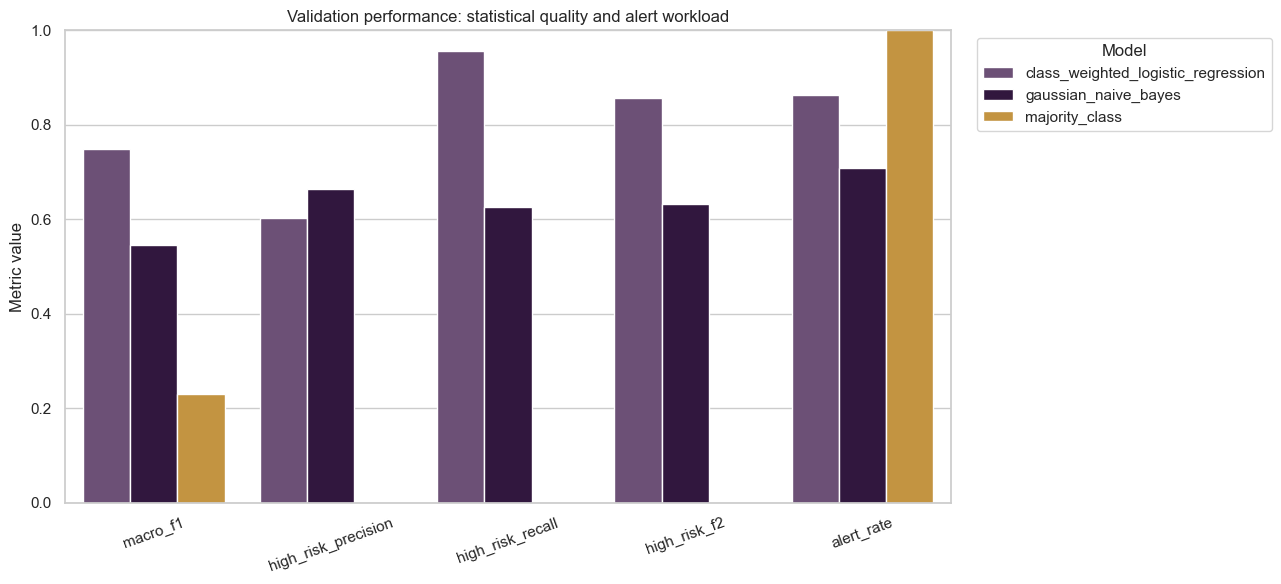

In [17]:
metrics_for_plot = [
    "macro_f1",
    "high_risk_precision",
    "high_risk_recall",
    "high_risk_f2",
    "alert_rate"]
validation_plot_data = validation_results.melt(
    id_vars="model",
    value_vars=metrics_for_plot,
    var_name="metric",
    value_name="value")

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=validation_plot_data,
    x="metric",
    y="value",
    hue="model",
    palette=["#6F4A7C", "#331045", "#D99A2B"],
    ax=ax)
ax.set_title("Validation performance: statistical quality and alert workload")
ax.set_xlabel("")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Baseline selection rule

The majority model is a reference, not a deployment candidate. Among the two ML baselines, selection prioritizes **high-risk F2**, then macro F1 and high-risk precision. This decision is made only from validation results.


In [18]:
ml_candidate_names = [
    "gaussian_naive_bayes",
    "class_weighted_logistic_regression"]
ml_candidates = validation_results[
    validation_results["model"].isin(ml_candidate_names)
].copy()
selected_model_name = (
    ml_candidates.sort_values(
        ["high_risk_f2", "macro_f1", "high_risk_precision"],
        ascending=False)
    .iloc[0]["model"])
selected_validation_metrics = validation_results.loc[
    validation_results["model"] == selected_model_name
].iloc[0]

print(f"Selected ML baseline: {selected_model_name}")
print(
    "Selection basis — "
    f"high-risk F2={selected_validation_metrics['high_risk_f2']:.4f}, "
    f"macro F1={selected_validation_metrics['macro_f1']:.4f}, "
    f"high-risk precision={selected_validation_metrics['high_risk_precision']:.4f}")


Selected ML baseline: class_weighted_logistic_regression
Selection basis — high-risk F2=0.8567, macro F1=0.7488, high-risk precision=0.6037


## 10. Final evaluation on the test period


We now generate test results. The selected model's test result is the primary out-of-time estimate. Test outputs for the two original baselines are also retained for backward compatibility and transparent comparison, but they do not change the selection decision.


In [19]:
for model_name, model in models.items():
    test_prediction = model.predict(X_test)
    test_probability = align_probabilities(
        model.predict_proba(X_test),
        model.classes_)
    test_outputs[model_name] = evaluate_predictions(
        model_name,
        "test",
        y_test,
        test_prediction,
        test_probability)

test_results = pd.DataFrame([output[0] for output in test_outputs.values()])
baseline_model_results = pd.concat(
    [validation_results.drop(columns=[], errors="ignore"), test_results],
    ignore_index=True)

display(
    test_results[
        [
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "high_risk_precision",
            "high_risk_recall",
            "high_risk_f2",
            "alert_rate",
            "false_alarm_rate",
            "high_risk_pr_auc"]].round(4))


,model,accuracy,balanced_accuracy,macro_f1,high_risk_precision,high_risk_recall,high_risk_f2,alert_rate,false_alarm_rate,high_risk_pr_auc
0,majority_class,0.5297,0.3333,0.2309,0.0000,0.0000,0.0000,1.0000,0.0000,0.3408
1,gaussian_naive_bayes,0.5680,0.6341,0.5606,0.6473,0.6463,0.6465,0.7111,0.1821,0.6655
2,class_weighted_logistic_regression,0.7204,0.7805,0.7405,0.5731,0.9736,0.8542,0.8613,0.3750,0.7715


In [20]:
selected_test_summary, selected_test_report, selected_test_matrix = test_outputs[selected_model_name]
print(f"Selected model: {selected_model_name}")
display(selected_test_matrix)
display(selected_test_report.round(4))

Selected model: class_weighted_logistic_regression


,pred_Low Risk,pred_Medium Risk,pred_High Risk
actual_Low Risk,2174,15,400
actual_Medium Risk,453,5597,4544
actual_High Risk,147,33,6637


,label,label_name,precision,recall,f1_score,support
0,0,Low Risk,0.7837,0.8397,0.8107,2589
1,1,Medium Risk,0.9915,0.5283,0.6893,10594
2,2,High Risk,0.5731,0.9736,0.7215,6817


## 11. Inspect feature relationships


In [21]:
# Calculate an ANOVA-style class-separation score using training data 
def calculate_univariate_feature_importance(X, y):
    values = X.to_numpy(dtype=float)
    labels = np.asarray(y, dtype=int)
    overall_mean = values.mean(axis=0)
    between = np.zeros(values.shape[1], dtype=float)
    within = np.zeros(values.shape[1], dtype=float)

    for risk_class in RISK_LABELS:
        class_values = values[labels == risk_class]
        if len(class_values) == 0:
            continue
        class_mean = class_values.mean(axis=0)
        between += len(class_values) * (class_mean - overall_mean) ** 2
        within += ((class_values - class_mean) ** 2).sum(axis=0)

    between_degrees = max(len(RISK_LABELS) - 1, 1)
    within_degrees = max(len(labels) - len(RISK_LABELS), 1)
    f_score = (between / between_degrees) / ((within / within_degrees) + 1e-12)

    result = pd.DataFrame(
        {"feature": X.columns, "f_score": f_score}
    ).replace([np.inf, -np.inf], np.nan)
    result["f_score"] = result["f_score"].fillna(0.0)
    result = result.sort_values("f_score", ascending=False).reset_index(drop=True)
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    return result


feature_importance = calculate_univariate_feature_importance(X_train, y_train)
display(feature_importance.head(20).round(4))


,rank,feature,f_score
0,1,no_sales_flag,"28,339.2743"
1,2,revenue_percentile_category_region,"26,360.0063"
2,3,customer_share_category_region,"20,910.6031"
3,4,unique_customers,"17,253.2658"
4,5,active_sales_reps,"17,190.8478"
5,6,order_count,"17,180.7584"
6,7,risk_factor_under_trend,"16,577.5793"
7,8,product_unit_share_category_region,"15,527.0405"
8,9,product_revenue_share_category_region,"15,322.4810"
9,10,covered_annual_quota_eur,"13,617.9201"


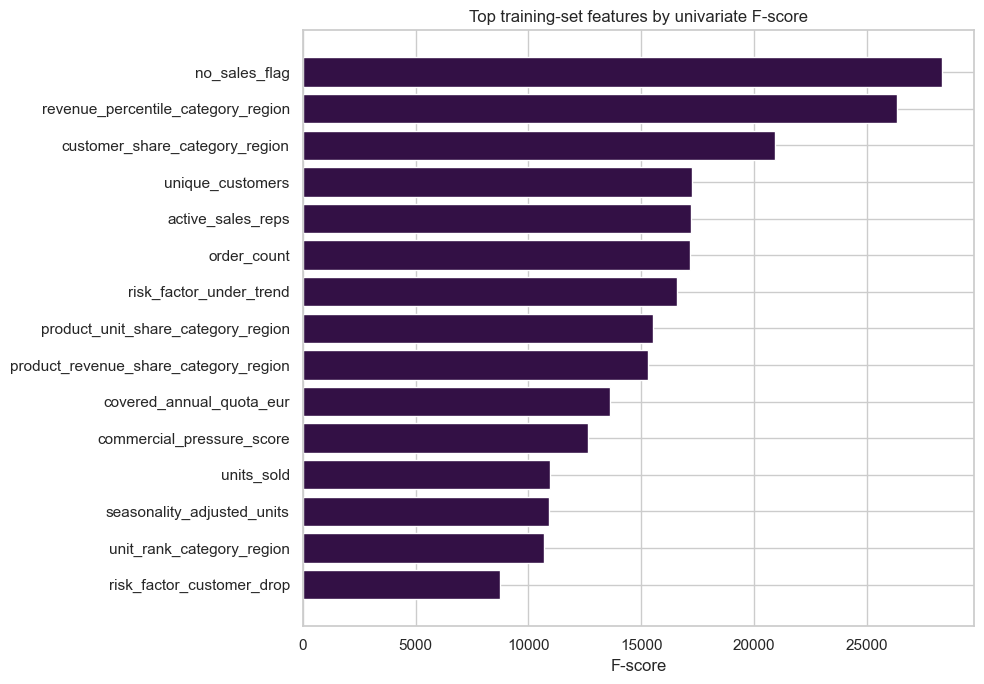

In [22]:
top_feature_plot = feature_importance.head(15).sort_values("f_score")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_feature_plot["feature"], top_feature_plot["f_score"], color="#331045")
ax.set_title("Top training-set features by univariate F-score")
ax.set_xlabel("F-score")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [22]:
def gaussian_class_drivers(model, X, top_n=30):
    feature_std = X.std(axis=0, ddof=0).replace(0, 1.0)
    overall_mean = X.mean(axis=0)
    result = pd.DataFrame({"feature": X.columns})

    standardized_columns = []
    for class_position, risk_class in enumerate(model.classes_):
        class_mean_column = f"class_{int(risk_class)}_{LABEL_NAMES[int(risk_class)]}"
        standardized_column = f"standardized_difference_class_{int(risk_class)}"
        class_means = pd.Series(model.theta_[class_position], index=X.columns)
        result[class_mean_column] = class_means.to_numpy()
        result[standardized_column] = ((class_means - overall_mean) / feature_std).to_numpy()
        standardized_columns.append(standardized_column)

    result["max_abs_class_mean"] = result[
        [column for column in result.columns if column.startswith("class_")]
    ].abs().max(axis=1)
    result["max_abs_standardized_difference"] = result[standardized_columns].abs().max(axis=1)
    return result.sort_values(
        "max_abs_standardized_difference", ascending=False
    ).head(top_n).reset_index(drop=True)


gaussian_nb_class_drivers = gaussian_class_drivers(
    gaussian_nb_model,
    X_train,
    top_n=30)
display(gaussian_nb_class_drivers.head(15).round(4))


,feature,class_0_Low Risk,standardized_difference_class_0,class_1_Medium Risk,standardized_difference_class_1,class_2_High Risk,standardized_difference_class_2,max_abs_class_mean,max_abs_standardized_difference
0,risk_factor_volatility,-0.9602,-0.9602,0.2348,0.2348,0.0880,0.0880,0.9602,0.9602
1,revenue_percentile_category_region,-0.6127,-0.6127,-0.3833,-0.3833,0.8816,0.8816,0.8816,0.8816
2,no_sales_flag,0.8248,0.8248,0.3133,0.3133,-0.8729,-0.8729,0.8729,0.8729
3,customer_share_category_region,-0.6669,-0.6669,-0.3192,-0.3192,0.8079,0.8079,0.8079,0.8079
4,risk_factor_under_trend,-0.7640,-0.7640,0.5123,0.5123,-0.4340,-0.4340,0.7640,0.7640
5,unique_customers,-0.6280,-0.6280,-0.2975,-0.2975,0.7560,0.7560,0.7560,0.7560
6,active_sales_reps,-0.6269,-0.6269,-0.2973,-0.2973,0.7551,0.7551,0.7551,0.7551
7,order_count,-0.6260,-0.6260,-0.2975,-0.2975,0.7550,0.7550,0.7550,0.7550
8,product_unit_share_category_region,-0.5193,-0.5193,-0.3190,-0.3190,0.7381,0.7381,0.7381,0.7381
9,product_revenue_share_category_region,-0.5195,-0.5195,-0.3165,-0.3165,0.7343,0.7343,0.7343,0.7343


In [28]:
def logistic_coefficient_table(model, feature_names):
    result = pd.DataFrame({"feature": feature_names})
    coefficient_columns = []
    for class_position, risk_class in enumerate(model.classes_):
        column = f"coefficient_class_{int(risk_class)}_{LABEL_NAMES[int(risk_class)]}"
        result[column] = model.coef_[class_position]
        coefficient_columns.append(column)
    result["max_abs_coefficient"] = result[coefficient_columns].abs().max(axis=1)
    result["dominant_class"] = result[coefficient_columns].abs().idxmax(axis=1)
    return result.sort_values("max_abs_coefficient", ascending=False).reset_index(drop=True)


logistic_coefficients = logistic_coefficient_table(logistic_model, X_train.columns)
display(logistic_coefficients.head(20).round(4))


,feature,coefficient_class_0_Low Risk,coefficient_class_1_Medium Risk,coefficient_class_2_High Risk,max_abs_coefficient,dominant_class
0,inventory_months_cover,-6.1451,3.0801,3.0650,6.1451,coefficient_class_0_Low Risk
1,units_vs_6m_avg_pct,-3.3469,1.6521,1.6949,3.3469,coefficient_class_0_Low Risk
2,no_sales_flag,1.1223,1.0385,-2.1608,2.1608,coefficient_class_2_High Risk
3,region__Eastern Europe,0.3128,1.2507,-1.5635,1.5635,coefficient_class_2_High Risk
4,mom_units_growth_pct,-1.3221,0.5647,0.7574,1.3221,coefficient_class_0_Low Risk
5,volatility_3m,-1.3104,1.0097,0.3007,1.3104,coefficient_class_0_Low Risk
6,revenue_volatility_3m,1.2558,-1.0007,-0.2552,1.2558,coefficient_class_0_Low Risk
7,customers_lag_1m,1.0827,-0.5736,-0.5091,1.0827,coefficient_class_0_Low Risk
8,trend_slope_3m,1.0659,-0.6621,-0.4038,1.0659,coefficient_class_0_Low Risk
9,revenue_vs_lag_1m_pct,-1.0622,0.6237,0.4385,1.0622,coefficient_class_0_Low Risk


## 12. Create row-level predictions with business keys


In [23]:
# Combine row identifiers, actual labels, predictions, and probabilities
def build_prediction_table(X, y, id_table):
    if id_table is not None:
        result = id_table.drop(columns=[TARGET_COL], errors="ignore").reset_index(drop=True).copy()
    else:
        result = pd.DataFrame({"row_number": np.arange(len(X), dtype=int)})

    result["actual_label"] = np.asarray(y, dtype=int)
    result["actual_label_name"] = result["actual_label"].map(LABEL_NAMES)

    for model_name, model in models.items():
        prediction = model.predict(X)
        probability = align_probabilities(model.predict_proba(X), model.classes_)
        result[f"{model_name}_predicted_label"] = prediction.astype(int)
        result[f"{model_name}_predicted_label_name"] = pd.Series(prediction).map(LABEL_NAMES).to_numpy()
        result[f"{model_name}_probability_low"] = probability[:, 0]
        result[f"{model_name}_probability_medium"] = probability[:, 1]
        result[f"{model_name}_probability_high"] = probability[:, 2]

    return result


validation_predictions = build_prediction_table(
    X_valid, y_valid, id_tables["valid"])
test_predictions = build_prediction_table(
    X_test, y_test, id_tables["test"])

display(
    validation_predictions[
        [
            column
            for column in validation_predictions.columns
            if column in {"product_id", "region_id", "target_month", "actual_label"}
            or selected_model_name in column]].head(8))


,product_id,region_id,target_month,actual_label,class_weighted_logistic_regression_predicted_label,class_weighted_logistic_regression_predicted_label_name,class_weighted_logistic_regression_probability_low,class_weighted_logistic_regression_probability_medium,class_weighted_logistic_regression_probability_high
0,1000,1,2024-07,2,2,High Risk,0.0500,0.0989,0.8511
1,1000,1,2024-08,2,1,Medium Risk,0.0078,0.5861,0.4061
2,1000,1,2024-09,1,1,Medium Risk,0.0033,0.9961,0.0005
3,1000,1,2024-10,2,2,High Risk,0.0001,0.0807,0.9192
4,1000,1,2024-11,1,2,High Risk,0.0833,0.2105,0.7061
5,1000,1,2024-12,2,2,High Risk,0.0218,0.0872,0.8910
6,1000,1,2025-01,1,1,Medium Risk,0.0751,0.9241,0.0007
7,1000,1,2025-02,2,2,High Risk,0.3218,0.2601,0.4180


## 13. Refit the selected baseline and score the latest month


Model selection and final testing are now complete. For operational scoring, the selected model can therefore be refitted on all labeled history. The preprocessing parameters remain train-fitted from the previous notebook, so the scoring transformation stays consistent.


In [24]:
scoring_predictions = None
final_selected_model = None

if X_scoring is not None:
    X_all_labeled = pd.concat([X_train, X_valid, X_test], ignore_index=True)
    y_all_labeled = pd.concat([y_train, y_valid, y_test], ignore_index=True)

    final_selected_model = clone(models[selected_model_name])
    final_selected_model.fit(X_all_labeled, y_all_labeled)

    scoring_prediction = final_selected_model.predict(X_scoring)
    scoring_probability = align_probabilities(
        final_selected_model.predict_proba(X_scoring),
        final_selected_model.classes_)

    if id_tables["scoring"] is not None:
        scoring_predictions = id_tables["scoring"].copy().reset_index(drop=True)
    else:
        scoring_predictions = pd.DataFrame(
            {"row_number": np.arange(len(X_scoring), dtype=int)})

    scoring_predictions["model_name"] = selected_model_name
    scoring_predictions["predicted_risk_label"] = scoring_prediction.astype(int)
    scoring_predictions["predicted_risk_label_name"] = pd.Series(scoring_prediction).map(LABEL_NAMES).to_numpy()
    scoring_predictions["probability_low_risk"] = scoring_probability[:, 0]
    scoring_predictions["probability_medium_risk"] = scoring_probability[:, 1]
    scoring_predictions["probability_high_risk"] = scoring_probability[:, 2]
    scoring_predictions["predicted_risk_score_0_10"] = (
        scoring_probability @ np.array([0.0, 5.0, 10.0]))
    scoring_predictions["alert_flag"] = (scoring_prediction > 0).astype(int)
    scoring_predictions["high_risk_alert_flag"] = (scoring_prediction == 2).astype(int)

    display(scoring_predictions.head(10))
    print("Scoring prediction distribution:")
    display(
        scoring_predictions["predicted_risk_label_name"]
        .value_counts(dropna=False)
        .rename("rows")
        .to_frame())
else:
    print("No scoring matrix was found. The labeled baseline evaluation is still complete.")


,product_id,year_month,region_id,region,target_month,model_name,predicted_risk_label,predicted_risk_label_name,probability_low_risk,probability_medium_risk,probability_high_risk,predicted_risk_score_0_10,alert_flag,high_risk_alert_flag
0,1000,2025-12,1,DACH,2026-01,class_weighted_logistic_regression,2,High Risk,0.1076,0.1410,0.7514,8.2188,1,1
1,1000,2025-12,10,APAC,2026-01,class_weighted_logistic_regression,1,Medium Risk,0.0056,0.9907,0.0037,4.9905,1,0
2,1000,2025-12,2,Western Europe,2026-01,class_weighted_logistic_regression,2,High Risk,0.0107,0.2443,0.7449,8.6710,1,1
3,1000,2025-12,3,Southern Europe,2026-01,class_weighted_logistic_regression,2,High Risk,0.0051,0.2478,0.7470,8.7094,1,1
4,1000,2025-12,4,Southern Europe,2026-01,class_weighted_logistic_regression,2,High Risk,0.3660,0.0647,0.5692,6.0159,1,1
5,1000,2025-12,5,Northern Europe,2026-01,class_weighted_logistic_regression,2,High Risk,0.0243,0.4124,0.5634,7.6955,1,1
6,1000,2025-12,6,North America,2026-01,class_weighted_logistic_regression,2,High Risk,0.0559,0.3603,0.5838,7.6398,1,1
7,1000,2025-12,7,North America,2026-01,class_weighted_logistic_regression,0,Low Risk,0.9741,0.0259,0.0001,0.1301,0,0
8,1000,2025-12,8,Benelux,2026-01,class_weighted_logistic_regression,1,Medium Risk,0.0081,0.9903,0.0016,4.9676,1,0
9,1000,2025-12,9,Eastern Europe,2026-01,class_weighted_logistic_regression,2,High Risk,0.1687,0.0413,0.7900,8.1069,1,1


Scoring prediction distribution:


,rows
predicted_risk_label_name,
High Risk,1097
Medium Risk,662
Low Risk,241


## 14. Recommendations and limitations


In [26]:
def recommendations_from_results(validation_table, training_distribution, selected_name):
    selected = validation_table.loc[validation_table["model"] == selected_name].iloc[0]
    high_share = float(
        training_distribution.loc[
            training_distribution["label"] == 2, "share"
        ].iloc[0])
    recommendations = []

    if high_share < 0.005:
        recommendations.append(
            {
                "priority": "High",
                "area": "Target definition and sample size",
                "recommendation": (
                    "High-risk observations are extremely rare. Validate the business thresholds, "
                    "extend the historical window if possible, and report confidence intervals or "
                    "month-by-month stability before production use.")})

    if selected["high_risk_recall"] < 0.60:
        recommendations.append(
            {
                "priority": "High",
                "area": "High-risk detection",
                "recommendation": (
                    "Validation high-risk recall is below 60%. Test tree-based class-weighted models "
                    "and tune the high-risk probability threshold on validation data only.")})

    if selected["high_risk_precision"] < 0.05:
        recommendations.append(
            {
                "priority": "High",
                "area": "Alert quality",
                "recommendation": (
                    "High-risk precision is very low. Define an acceptable review capacity and tune "
                    "thresholds against precision, recall, alert volume, and the cost of missed risks.")})

    if selected["alert_rate"] > 0.20:
        recommendations.append(
            {
                "priority": "Medium",
                "area": "Operational workload",
                "recommendation": (
                    "The model flags more than 20% of rows. Add an alert-volume guardrail and rank "
                    "alerts by predicted probability or expected revenue at risk.")})

    recommendations.extend(
        [
            {
                "priority": "Medium",
                "area": "Next model",
                "recommendation": (
                    "Compare class-weighted Random Forest and gradient-boosted trees. Keep the same "
                    "chronological split and validation-first selection policy.")},
            {
                "priority": "Medium",
                "area": "Probability quality",
                "recommendation": (
                    "Assess probability calibration before interpreting scores as risk likelihoods. "
                    "Use time-aware calibration and reliability plots once more positive cases exist.")},
            {
                "priority": "Medium",
                "area": "Stability",
                "recommendation": (
                    "Add walk-forward validation by month and monitor recall, precision, alert rate, "
                    "feature drift, and calibration over time.")}])
    return pd.DataFrame(recommendations).drop_duplicates("area").reset_index(drop=True)


baseline_recommendations = recommendations_from_results(
    validation_results,
    train_target_distribution,
    selected_model_name)
display(baseline_recommendations)


,priority,area,recommendation
0,Medium,Operational workload,The model flags more than 20% of rows. Add an ...
1,Medium,Next model,Compare class-weighted Random Forest and gradi...
2,Medium,Probability quality,Assess probability calibration before interpre...
3,Medium,Stability,Add walk-forward validation by month and monit...


## 15. Export


In [27]:
# Target distributions — preserve the original column names.
train_target_distribution.drop(columns="split").to_csv(
    OUTPUT_DIR / "train_target_distribution.csv", index=False)
valid_target_distribution.drop(columns="split").to_csv(
    OUTPUT_DIR / "valid_target_distribution.csv", index=False)
test_target_distribution.drop(columns="split").to_csv(
    OUTPUT_DIR / "test_target_distribution.csv", index=False)

export_stems = {
    ("majority_class", "valid"): "majority_valid",
    ("majority_class", "test"): "majority_test",
    ("gaussian_naive_bayes", "valid"): "gaussian_naive_bayes_valid",
    ("gaussian_naive_bayes", "test"): "gaussian_naive_bayes_test",
    ("class_weighted_logistic_regression", "valid"): "class_weighted_logistic_regression_valid",
    ("class_weighted_logistic_regression", "test"): "class_weighted_logistic_regression_test"}

for (model_name, split), stem in export_stems.items():
    output = validation_outputs[model_name] if split == "valid" else test_outputs[model_name]
    summary, class_report, matrix = output
    class_report.to_csv(OUTPUT_DIR / f"{stem}_classification_report.csv", index=False)
    matrix.to_csv(OUTPUT_DIR / f"{stem}_confusion_matrix.csv")
    with open(OUTPUT_DIR / f"{stem}_summary_metrics.json", "w", encoding="utf-8") as file:
        json.dump(summary, file, indent=2)

baseline_model_results.to_csv(
    OUTPUT_DIR / "baseline_model_results.csv", index=False)
feature_importance.to_csv(
    OUTPUT_DIR / "feature_importance_univariate_f_score.csv", index=False)
gaussian_nb_class_drivers.to_csv(
    OUTPUT_DIR / "feature_importance_naive_bayes_class_drivers.csv", index=False)
logistic_coefficients.to_csv(
    OUTPUT_DIR / "feature_importance_logistic_regression_coefficients.csv", index=False)
baseline_recommendations.to_csv(
    OUTPUT_DIR / "baseline_recommendations.csv", index=False)
validation_predictions.to_csv(
    OUTPUT_DIR / "baseline_validation_predictions.csv", index=False)
test_predictions.to_csv(
    OUTPUT_DIR / "baseline_test_predictions.csv", index=False)
pd.DataFrame({"feature": X_train.columns, "feature_position": np.arange(X_train.shape[1])}).to_csv(
    OUTPUT_DIR / "model_input_feature_list.csv", index=False)

if scoring_predictions is not None:
    scoring_predictions.to_csv(
        OUTPUT_DIR / "scoring_baseline_predictions.csv", index=False)

for model_name, model in models.items():
    joblib.dump(model, OUTPUT_DIR / f"{model_name}_baseline.joblib")
if final_selected_model is not None:
    joblib.dump(final_selected_model, OUTPUT_DIR / "selected_baseline_model_refit.joblib")


NameError: name 'logistic_coefficients' is not defined

In [28]:
metric_dictionary = pd.DataFrame(
    [
        {"metric": "accuracy", "purpose": "Overall correct prediction share; misleading on its own for imbalanced targets."},
        {"metric": "balanced_accuracy", "purpose": "Average recall across classes, giving each class equal importance."},
        {"metric": "macro_f1", "purpose": "Average class F1 without weighting by class size."},
        {"metric": "weighted_f1", "purpose": "Average class F1 weighted by class frequency."},
        {"metric": "high_risk_precision", "purpose": "Share of high-risk alerts that are truly high risk."},
        {"metric": "high_risk_recall", "purpose": "Share of actual high-risk cases detected."},
        {"metric": "high_risk_f2", "purpose": "High-risk precision/recall balance with extra weight on recall."},
        {"metric": "alert_rate", "purpose": "Share predicted as medium or high risk; proxy for review workload."},
        {"metric": "false_alarm_rate", "purpose": "Share of non-high-risk rows incorrectly flagged as high risk."},
        {"metric": "high_risk_pr_auc", "purpose": "Ranking quality for the rare high-risk class across thresholds."},
        {"metric": "macro_roc_auc_ovr", "purpose": "Average one-vs-rest ranking quality across all classes."},
        {"metric": "log_loss", "purpose": "Probability error that penalizes confident incorrect predictions."}])
metric_dictionary.to_csv(
    OUTPUT_DIR / "model_evaluation_metric_dictionary.csv", index=False)
display(metric_dictionary)


,metric,purpose
0,accuracy,Overall correct prediction share; misleading o...
1,balanced_accuracy,"Average recall across classes, giving each cla..."
2,macro_f1,Average class F1 without weighting by class size.
3,weighted_f1,Average class F1 weighted by class frequency.
4,high_risk_precision,Share of high-risk alerts that are truly high ...
5,high_risk_recall,Share of actual high-risk cases detected.
6,high_risk_f2,High-risk precision/recall balance with extra ...
7,alert_rate,Share predicted as medium or high risk; proxy ...
8,false_alarm_rate,Share of non-high-risk rows incorrectly flagge...
9,high_risk_pr_auc,Ranking quality for the rare high-risk class a...


## 16. Final quality checks


In [29]:
original_required_outputs = [
    "train_target_distribution.csv",
    "valid_target_distribution.csv",
    "test_target_distribution.csv",
    "majority_valid_classification_report.csv",
    "majority_valid_confusion_matrix.csv",
    "majority_valid_summary_metrics.json",
    "majority_test_classification_report.csv",
    "majority_test_confusion_matrix.csv",
    "majority_test_summary_metrics.json",
    "gaussian_naive_bayes_valid_classification_report.csv",
    "gaussian_naive_bayes_valid_confusion_matrix.csv",
    "gaussian_naive_bayes_valid_summary_metrics.json",
    "gaussian_naive_bayes_test_classification_report.csv",
    "gaussian_naive_bayes_test_confusion_matrix.csv",
    "gaussian_naive_bayes_test_summary_metrics.json",
    "baseline_model_results.csv",
    "feature_importance_univariate_f_score.csv",
    "feature_importance_naive_bayes_class_drivers.csv",
    "baseline_recommendations.csv"]

required_legacy_metric_columns = {
    "model",
    "split",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "high_risk_recall"}

final_checks = {
    "feature_columns_match_across_splits": all(feature_alignment.values()),
    "target_is_not_a_feature": TARGET_COL not in X_train.columns,
    "identifiers_are_not_features": not any(column.endswith("_id") for column in X_train.columns),
    "feature_matrices_have_no_missing_values": matrix_quality["missing_feature_values"].eq(0).all(),
    "feature_matrices_have_no_infinite_values": matrix_quality["infinite_feature_values"].eq(0).all(),
    "all_expected_target_classes_exist_in_train": set(RISK_LABELS).issubset(set(y_train.unique())),
    "selected_model_is_an_ml_candidate": selected_model_name in ml_candidate_names,
    "validation_probabilities_sum_to_one": all(
        np.allclose(model.predict_proba(X_valid).sum(axis=1), 1.0)
        for model in models.values()),
    "validation_prediction_rows_match": len(validation_predictions) == len(X_valid),
    "test_prediction_rows_match": len(test_predictions) == len(X_test),
    "scoring_prediction_rows_match": scoring_predictions is None or len(scoring_predictions) == len(X_scoring),
    "legacy_metric_columns_preserved": required_legacy_metric_columns.issubset(baseline_model_results.columns),
    "original_output_files_preserved": all((OUTPUT_DIR / name).exists() for name in original_required_outputs)}

if not chronology_summary.empty:
    final_checks["chronological_split_order"] = train_end < valid_start <= valid_end < test_start

quality_check_table = pd.DataFrame(
    {"check": list(final_checks.keys()), "passed": list(final_checks.values())})
display(quality_check_table)

failed_checks = quality_check_table.loc[~quality_check_table["passed"], "check"].tolist()
if failed_checks:
    raise AssertionError("Failed final checks: " + ", ".join(failed_checks))

print("All final ML baseline checks passed.")


,check,passed
0,feature_columns_match_across_splits,True
1,target_is_not_a_feature,True
2,identifiers_are_not_features,True
3,feature_matrices_have_no_missing_values,True
4,feature_matrices_have_no_infinite_values,True
5,all_expected_target_classes_exist_in_train,True
6,selected_model_is_an_ml_candidate,True
7,validation_probabilities_sum_to_one,True
8,validation_prediction_rows_match,True
9,test_prediction_rows_match,True


All final ML baseline checks passed.


In [30]:
baseline_evaluation_report = {
    "train_shape": list(X_train.shape),
    "valid_shape": list(X_valid.shape),
    "test_shape": list(X_test.shape),
    "scoring_shape": None if X_scoring is None else list(X_scoring.shape),
    "majority_class_label": int(majority_model.classes_[np.argmax(majority_model.class_prior_)]),
    "selected_model": selected_model_name,
    "selection_rule": "Highest validation high-risk F2, then macro F1, then high-risk precision; majority reference excluded.",
    "summary_metrics": baseline_model_results.to_dict(orient="records"),
    "top_15_features_univariate_f_score": feature_importance.head(15).to_dict(orient="records"),
    "target_distribution": target_distribution_all.to_dict(orient="records"),
    "recommendations": baseline_recommendations.to_dict(orient="records"),
    "final_checks": final_checks}
with open(OUTPUT_DIR / "baseline_evaluation_report.json", "w", encoding="utf-8") as file:
    json.dump(baseline_evaluation_report, file, indent=2, default=str)

with open(OUTPUT_DIR / "selected_baseline_model.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "selected_model": selected_model_name,
            "selection_rule": baseline_evaluation_report["selection_rule"],
            "validation_metrics": selected_validation_metrics.to_dict(),
            "test_metrics": selected_test_summary,
            "refitted_on_all_labeled_rows_for_scoring": final_selected_model is not None},
        file,
        indent=2,
        default=str)

with open(OUTPUT_DIR / "ml_baseline_quality_report.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "matrix_quality": matrix_quality.to_dict(orient="records"),
            "feature_alignment": feature_alignment,
            "chronology": chronology_summary.to_dict(orient="records"),
            "final_checks": final_checks},
        file,
        indent=2,
        default=str)


In [31]:
export_summary = pd.DataFrame(
    [
        {
            "file": path.name,
            "size_bytes": path.stat().st_size}
        for path in sorted(OUTPUT_DIR.iterdir())
        if path.is_file()])
display(export_summary)

print("\nML baseline evaluation complete")
print("-" * 80)
print(f"Train rows:              {len(X_train):,}")
print(f"Validation rows:         {len(X_valid):,}")
print(f"Test rows:               {len(X_test):,}")
print(f"Model input features:    {X_train.shape[1]:,}")
print(f"Selected baseline:       {selected_model_name}")
print(f"Scoring rows:            {0 if X_scoring is None else len(X_scoring):,}")
print(f"Output folder:           {OUTPUT_DIR.resolve()}")


,file,size_bytes
0,baseline_evaluation_report.json,9614
1,baseline_model_results.csv,1701
2,baseline_recommendations.csv,685
3,baseline_test_predictions.csv,4289182
4,baseline_validation_predictions.csv,3430928
5,class_weighted_logistic_regression_baseline.jo...,13743
6,class_weighted_logistic_regression_test_classi...,276
7,class_weighted_logistic_regression_test_confus...,141
8,class_weighted_logistic_regression_test_summar...,644
9,class_weighted_logistic_regression_valid_class...,275



ML baseline evaluation complete
--------------------------------------------------------------------------------
Train rows:              82,000
Validation rows:         16,000
Test rows:               20,000
Model input features:    235
Selected baseline:       class_weighted_logistic_regression
Scoring rows:            2,000
Output folder:           C:\Benutzer\Anastasia\Lokale Daten\AS Portfolio\early-warning\data\full_data\ml_baseline
